## Here are all of the imports I am using & The reason I am using them.

* Importing PyTorch to build and train the neural network.
* Using utils.data for tensor dataset, dataloader for organizing data into batches for training the model.
* Importing pandas to read in the csv files and work with the data in tables.
* Importing Numpy to handle the calculations in histograms and arrays
* Importing matplotlib to plot graphs & visualize the data.

* Using sklearn.preprocessing to import standard scaler for scaling features & making sure they are on the same range.
* Using sklearn.metrics to import accuracy_score for measuring how often the model is correct.
* Using sklearn.linear_model to import LogisticRegression for estimating the impact of the Features
* Using sklearn.model_selection to import train_test_split for splitting up the data into training and testing sets.

## Then I load & assign the three kaggle csv files needed for the challenge.
* train.csv is used to train the model
* test.csv is used for final predictions
* sample_submission.csv is the required output format.

In [1]:
import torch # Importing PyTorch to build and train the neural network.
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader # Using utils.data for tensor dataset, dataloader for organizing data into batches for training the model.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.preprocessing import StandardScaler # Using sklearn.preprocessing to import standard scaler for scaling features & making sure they are on the same range.
from sklearn.metrics import accuracy_score # Using sklearn.metrics to import accuracy_score for measuring how often the model is correct.
from sklearn.linear_model import LogisticRegression # Using sklearn.linear_model to import LogisticRegression for estimating the impact of the Features
from sklearn.model_selection import train_test_split as make_samples # Using sklearn.model_selection to import train_test_split for splitting up the data into training and testing sets.

train = pd.read_csv("train.csv") # Loading the three kaggle files needed for the challenge.
test = pd.read_csv("test.csv")
sample_submission = pd.read_csv("sample_submission.csv")

## Here I am looking at the head first to check the first couple training rows.

In [2]:
train.head() # Looking at the head first to check the first couple training rows.

,id,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,label
0,1,4,99,76,15,51,23.2,0.223,21,0
1,2,0,102,52,0,0,25.1,0.078,21,0
2,3,3,126,88,41,235,39.3,0.704,27,0
3,4,5,109,75,26,0,36.0,0.546,60,0
4,5,4,156,75,0,0,48.3,0.238,32,1


## Then I check how many rows + columns are in each file to further confirm the files are there properly.

In [3]:
train.shape, test.shape, sample_submission.shape # Checking how many rows + columns are in each file to further confirm the files.

((600, 10), (168, 9), (168, 2))

## After I check the data types that are in the columns & then display them.

In [4]:
train.dtypes # Checking the data types in the columns.

id                            int64
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
label                         int64
dtype: object

## Here I check if there are any values missing within the dataset to find bad data to clean.
* Using isnull().sum() to check for null values.

In [5]:
train.isnull().sum(), test.isnull().sum() # Checking if there are any values missing within the dataset to find bad data to clean.

(id                          0
 Pregnancies                 0
 Glucose                     0
 BloodPressure               0
 SkinThickness               0
 Insulin                     0
 BMI                         0
 DiabetesPedigreeFunction    0
 Age                         0
 label                       0
 dtype: int64,
 id                          0
 Pregnancies                 0
 Glucose                     0
 BloodPressure               0
 SkinThickness               0
 Insulin                     0
 BMI                         0
 DiabetesPedigreeFunction    0
 Age                         0
 dtype: int64)

 ## Defining and checking the class of the target's before preparing the data to be trained. 
 * With train[Target].value_counts is based off of label 0 or 1, to make sure if the data is evenly split or not.

In [6]:
Target = "label"
ID = "id"

train[Target].value_counts(normalize=True) # Defining and checking the class of the target's before preparing the data to be trained. (Based off of label 0 or 1, to make sure if the data is evenly split or not.)

label
0    0.64
1    0.36
Name: proportion, dtype: float64

In [7]:
# Listing the full set of features for the neural network.
Features = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"]

## Here I define what the outliers are for each feature, using the IQR method (Q3 - Q1) and defining the upper and lower range of the data.
* I am not removing anything from the data; this is just to show the data in a future boxplot.

In [8]:
OutliersInData = []

for feature in Features:
    Q1 = train[feature].quantile(0.25) # I define the lower quantile
    Q3 = train[feature].quantile(0.75) # I define the upper quantile
    IQR = Q3 - Q1                      # Then I define an outlier by using the IQR above / below.
    
    Lower_Range = Q1 - 1.5 * IQR
    Upper_Range = Q3 + 1.5 * IQR

    Number_Of_Outliers = train[(train[feature] < Lower_Range) | (train[feature] > Upper_Range)].shape[0]

    OutliersInData.append({"Feature": feature, "Lower_Range": Lower_Range, "Upper_Range": Upper_Range, "Number_Of_Outliers": Number_Of_Outliers})

OutliersInData = pd.DataFrame(OutliersInData)
OutliersInData

,Feature,Lower_Range,Upper_Range,Number_Of_Outliers
0,Pregnancies,-6.50000,13.50000,2
1,Glucose,34.12500,207.12500,2
2,BloodPressure,40.00000,104.00000,28
3,SkinThickness,-48.00000,80.00000,1
4,Insulin,-193.87500,323.12500,26
5,BMI,13.68750,50.18750,13
6,DiabetesPedigreeFunction,-0.31775,1.17825,24
7,Age,-1.50000,66.50000,9


## Using FeatureSummary, I can show a clear summary of each feature so I can describe the dataset properly
* It will let me see what type of data I'm working with, the values & their range, and also if anything is missing; as well as how many outliers there are for each feature.

In [9]:
FeatureSummary = [] # Making a list to define the features and what they are: If they are numerical, categorical or have outliers, missing values, etc and specifying the range.

for feature in Features:
    FeatureSummary.append({"Feature": feature, "Type": "Numerical", "Range": str(train[feature].min()) + " to " + str(train[feature].max()), "Missing_Values": train[feature].isnull().sum(),
                           "Outliers": OutliersInData.loc[OutliersInData["Feature"] == feature, "Number_Of_Outliers"].values[0]})

FeatureSummary = pd.DataFrame(FeatureSummary)
FeatureSummary

,Feature,Type,Range,Missing_Values,Outliers
0,Pregnancies,Numerical,0 to 14,0,2
1,Glucose,Numerical,0 to 199,0,2
2,BloodPressure,Numerical,0 to 122,0,28
3,SkinThickness,Numerical,0 to 99,0,1
4,Insulin,Numerical,0 to 846,0,26
5,BMI,Numerical,0.0 to 53.2,0,13
6,DiabetesPedigreeFunction,Numerical,0.078 to 2.329,0,24
7,Age,Numerical,21 to 81,0,9


## Then TargetSummary will help define what each target is, and how each target is encoded.
* 0 means no diabetes, and 1 means the person has diabetes.

In [10]:
# Showing how the each target is encoded. (If it's a category, if it's a binary value, if they have diabetes or not and if there's a missing value.)
TargetSummary = pd.DataFrame({"Target": [Target], "Type": ["Categorical / Binary"], "Values": ["0 = No Diabetes, 1 = Has Diabetes"], "Missing_Values": [train[Target].isnull().sum()]})
TargetSummary

,Target,Type,Values,Missing_Values
0,label,Categorical / Binary,"0 = No Diabetes, 1 = Has Diabetes",0


## I first seperate the training data by class so the distributions can be compared by the plot
* After that, I compare label 0 vs label 1 and show the boxplot next to the graph to show the possible outliers for each label.

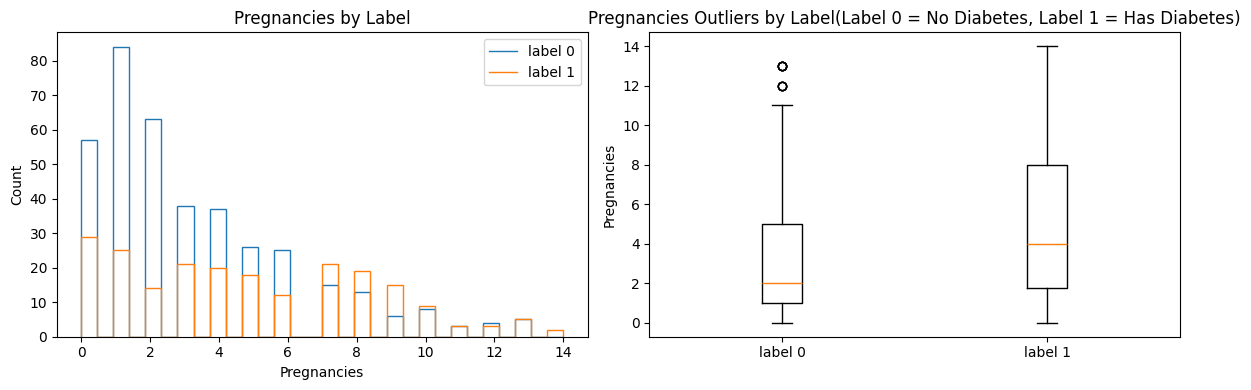

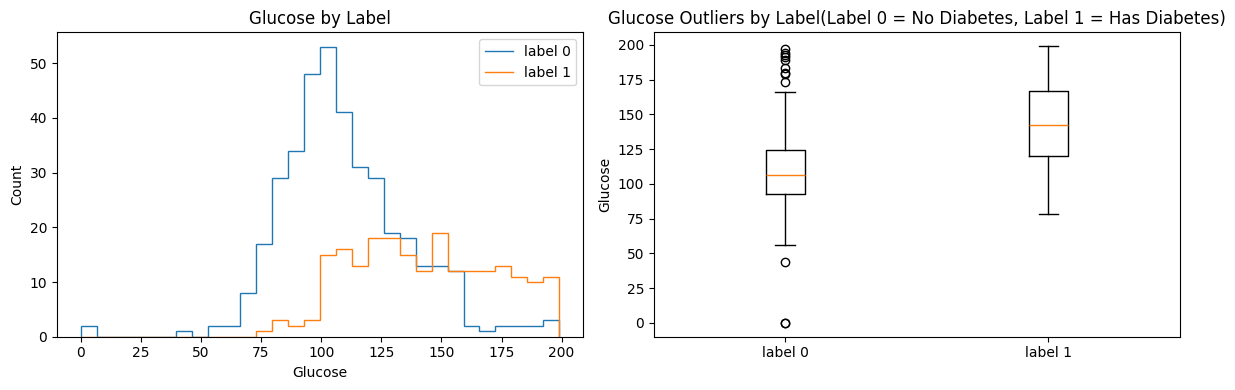

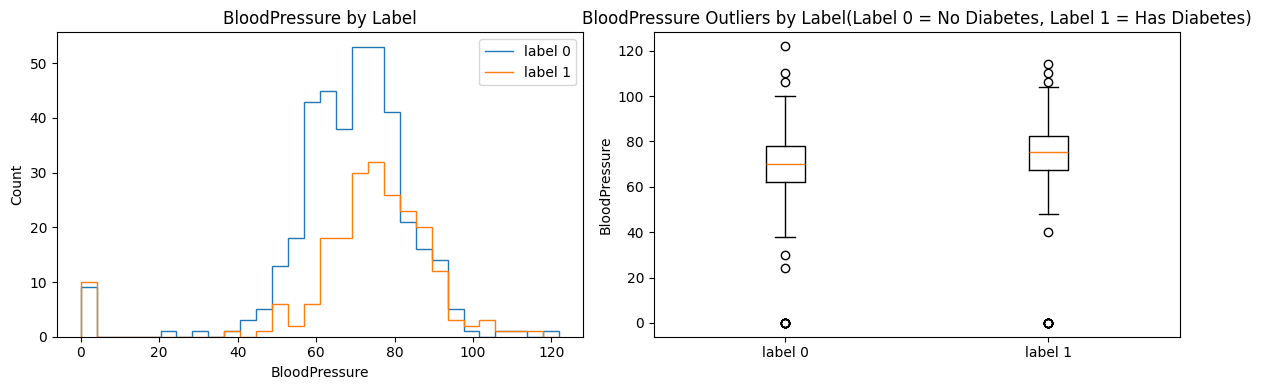

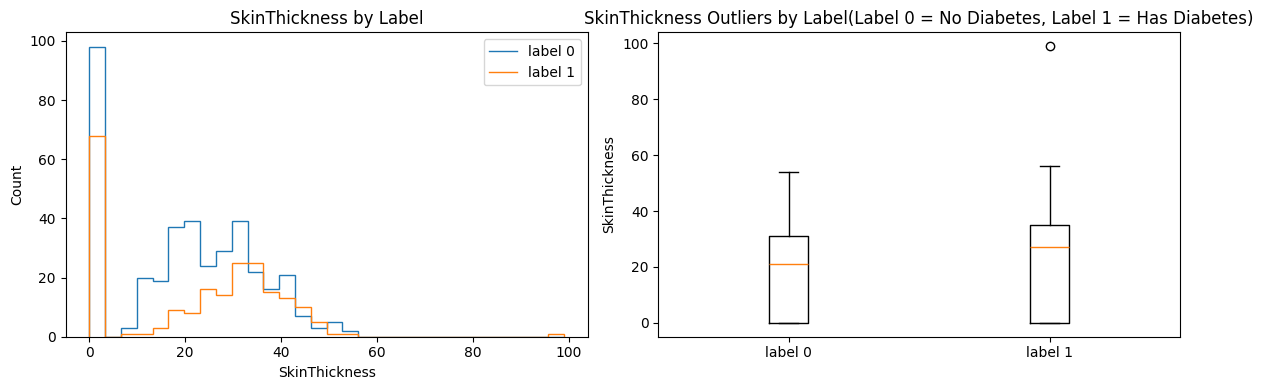

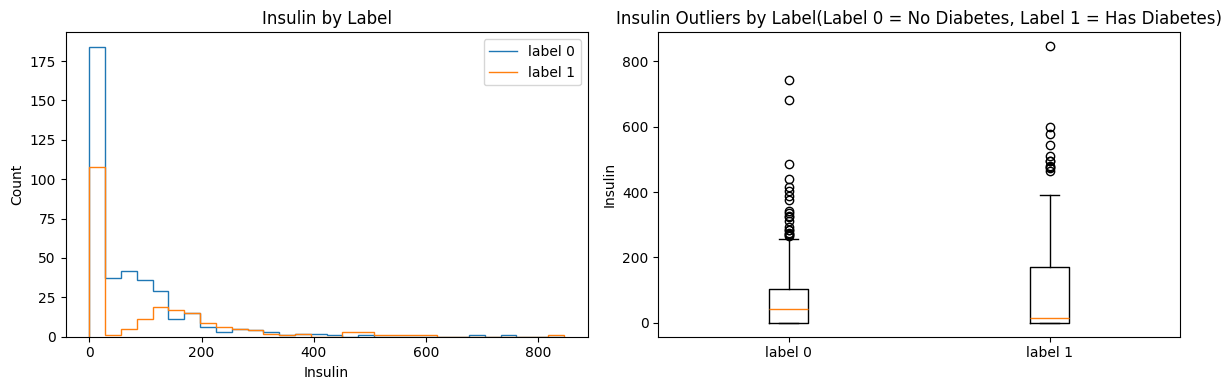

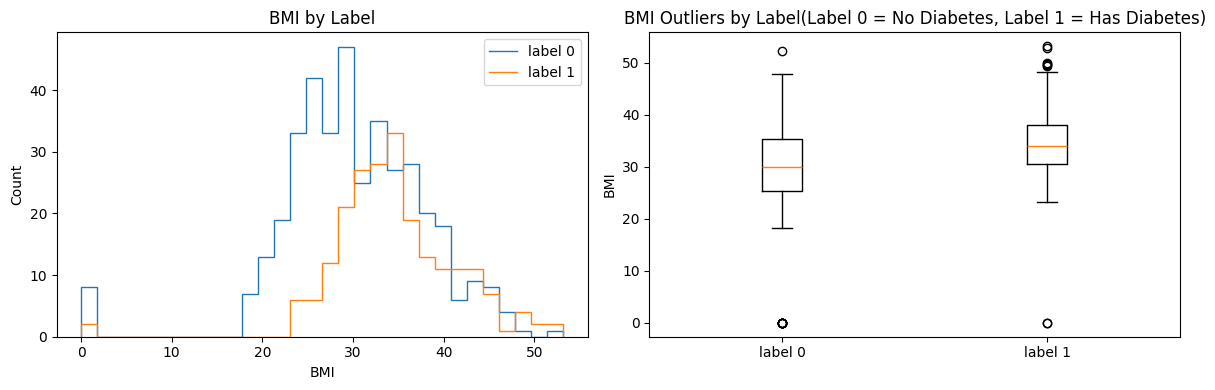

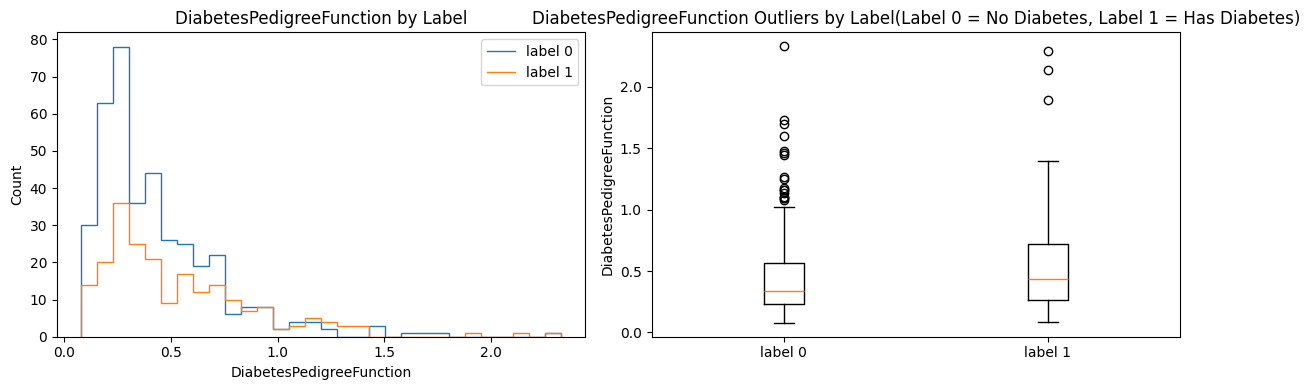

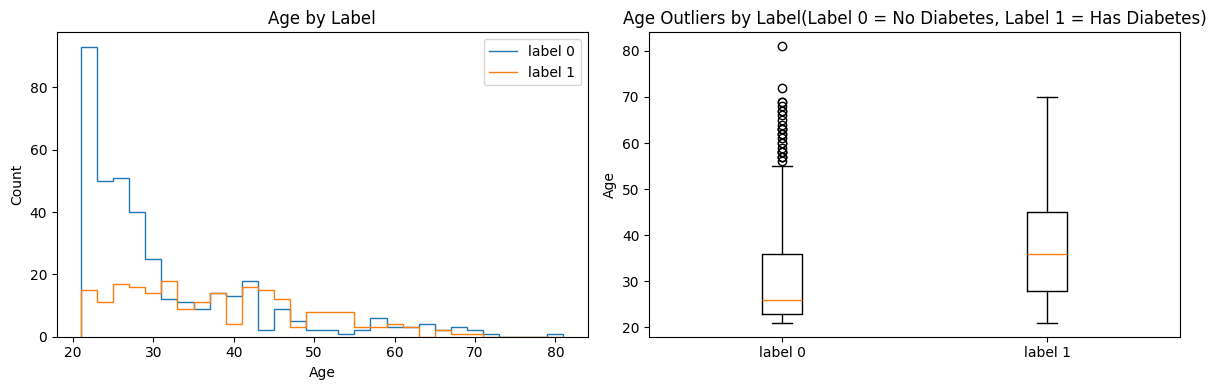

In [11]:
df_0 = train[train[Target] == 0] # Seperating the training data by which class so the distributions can be compared by the plot.
df_1 = train[train[Target] == 1]

for feature in Features:        # Plotting each feature on a histogram to see which variables may prove my prediction. (Difference between label 0 and label 1)
    plt.figure(figsize=(12, 4)) # As well as a box plot to see which variables may have outliers.   

    bins = np.histogram_bin_edges(train[feature], bins=30)
    count_0, _ = np.histogram(df_0[feature], bins=bins) # Checking how many values fall into each bin to then address with stairs for a histogram so both use the same number of bins.
    count_1, _ = np.histogram(df_1[feature], bins=bins) # Checking how many values fall into each bin to then address with stairs for a histogram so both use the same number of bins.

    plt.subplot(1, 2, 1)
    plt.stairs(count_0, bins, label="label 0") # Calls stairs and plots them on the histogram and labels them.
    plt.stairs(count_1, bins, label="label 1") # Calls stairs and plots them on the histogram and labels them.
    plt.xlabel(feature)
    plt.ylabel("Count")
    plt.title(feature + " by Label")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.boxplot([df_0[feature], df_1[feature]], tick_labels=["label 0", "label 1"])
    plt.ylabel(feature)
    plt.title(feature + " Outliers by Label(Label 0 = No Diabetes, Label 1 = Has Diabetes)")

    plt.tight_layout()
    plt.show()

## Here I focus on singling out a few of the features of my dataset (BMI, Age, and SkinThickness) to check if I can determine a pattern before using the full model.
* So I am asking the question, and trying to determine an answer to "Do people with diabetes tend to have higher or lower values for each of these features?"
* The correlation will help to give a rough idea of how strongly each feature is related to the label (It isn't perfect, But it can help give a little bit more insight into the data.)

In [88]:
RiskFeatures = ["Age", "BMI", "SkinThickness"] # I am using these three medical features and singling them out to determine if one of these have a stronger impact on having diabetes.

train.groupby(Target)[RiskFeatures].mean()  # I am using groupby and the mean to compare the RiskFeatures values for diabetic and non-diabetic people.
                                            # In other words, for people with label 0 and label 1, I am answering 'what are the avg BP, BMI and SkinThickness values?
                                            # This gives me a side-by-side comparision between both groups.

RiskFactor = train[RiskFeatures + [Target]].corr() # Then correlating that to try and estimate which feature relates to the label.
RiskFactor[Target]                                 # Postitive correlation means the higher values tend to appear more often - with having a high correlation with diabetes.
                                                   # Having a closer to 0 score means there is a weaker relationship / weaker correlation with having diabetes.

Age              0.264931
BMI              0.265475
SkinThickness    0.070603
label            1.000000
Name: label, dtype: float64

## This part is to help interpret the data.
* X_risk holds the three RiskFeatures defined above.
* y_risk holds the correct diabetes labels.
* X_risk_train / X_risk_train is used to train and test the Logistic Regression to see if it is working properly.
* Then I split the RiskFeature data into one part to train the Logistic Regression through risk_scaler = StandardScaler()
* After, I scale the features to compare them more fairly with each other. Since if I don't scale them, one feature could look more important than one of the others.

In [89]:
# X_risk is made for only the three risk features that I picked. (BloodPressure, BMI, and SkinThickness)
# y_risk is made for the answers to those rows (Label 0 or Label 1)
X_risk = train[RiskFeatures] # Then I prepare the risk features for a logistic regression model.
y_risk = train[Target]

# I split up the risk feature data into two; training samples and testing samples.
# X_risk_train is made for the RiskFeature data that will be used to train the Logistic Regression.
# X_risk_test is made for the RiskFeature data that will be used to test the Logistic Regression to see if it is properly working.
# y_risk_train is made to make sure X_risk_train has the correct labels.
# y_risk_test is made to make sure X_risk_test has the correct labels.
X_risk_train, X_risk_test, y_risk_train, y_risk_test = make_samples(X_risk, y_risk, test_size=0.2, random_state=42, stratify=y_risk)

risk_scaler = StandardScaler() # Then I scale it so the Logistic Regression Coefficients can be compared on the same range / scale as the rest of the data.

X_risk_train = risk_scaler.fit_transform(X_risk_train) # Fits the scaler on the training data 
X_risk_test = risk_scaler.transform(X_risk_test) # Then applies that same scaling to the test data.

risk_model = LogisticRegression() # Training the logistic regression to figure out the impact of each feature.
risk_model.fit(X_risk_train, y_risk_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

## This table shows exactly which feature has a stronger impact factor by checking the strongest effect in logistic regression.
* The impact_factor comes from the coefficient of the model
* The factor_ratio is the coefficient turned into a ratio to compare it.

In [90]:
# Finding which coefficients make an impact / effect on the model, and the ratio that they give to see what feature impacts what.
Risk_Impact = pd.DataFrame({"Feature": RiskFeatures, "impact_factor": risk_model.coef_[0], "factor_ratio": np.exp(risk_model.coef_[0])}).sort_values(by="impact_factor", ascending=False)
Risk_Impact

,Feature,impact_factor,factor_ratio
1,BMI,0.789735,2.202813
0,Age,0.537568,1.711839
2,SkinThickness,-0.165191,0.847732


## Then I look to visualize the above data.
* It looks like BMI has a very high impact, and Age is a decent factor in whether or not someone has diabetes or not!
* However, it looks like SkinThickness has a negative impact, actually!

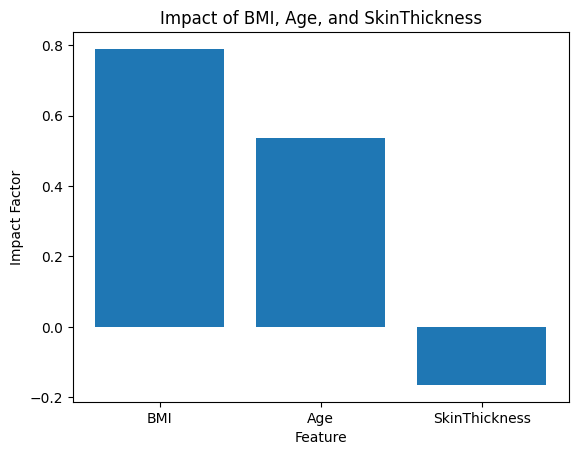

In [92]:
plt.bar(Risk_Impact["Feature"], Risk_Impact["impact_factor"]) # Visualizing the data.
plt.xlabel("Feature")
plt.ylabel("Impact Factor")
plt.title("Impact of BMI, Age, and SkinThickness")
plt.show()

## Trying to make sense of the graph above, I looked to the internet to get an explaination.
### To explain why BMI impacts whether someone would have diabetes or not I found:
* "Higher BMI, particularly with excess abdominal fat, increases diabetes risk by triggering insulin resistance, where cells stop responding effectively to insulin, causing the pancreas to overproduce it until it fails. This excess fat promotes inflammation and metabolic changes that impede glucose absorption, leading to high blood sugar."
* Source: https://pmc.ncbi.nlm.nih.gov/articles/PMC8740746/

### To explain why Age impacts whether someone would have diabetes or not I found:
* "Higher age increases diabetes risk primarily due to increased insulin resistance, reduced pancreatic function, and age-related physical changes. As people age, they often experience increased visceral fat, loss of muscle mass (sarcopenia), reduced physical activity, and changes in glucose metabolism, all of which raise blood sugar levels."
* Source: https://pmc.ncbi.nlm.nih.gov/articles/PMC5509969/

### To explain why SkinThickness impacts whether someone would have diabetes or not I found:
* "Increased skin thickness is generally associated with higher insulin levels or collagen structural changes, whereas a thinner dermis is linked to the hyperglycemia and tissue damage caused by Type 2 diabetes. People with thicker, healthy skin may have normal insulin sensitivity and lower glucose levels, as studies show that skin thins and collagen breaks down as diabetes progresses."
* Source: https://pmc.ncbi.nlm.nih.gov/articles/PMC9962953/

## Here I switch from the smaller RiskFeature features that I used to the full prediction model.
* X uses all 8 features
* Y is the known labels.
* X_Kaggle is the final test data with no labels.

In [85]:
# Preparing all of the feature set for the neural network.
X = train[Features]
y = train[Target]
X_Kaggle = test[Features]

## Then I split train.csv into training data and validation data.

In [86]:
X_train, X_validate, y_train, y_validate = make_samples(X, y, test_size=0.2, random_state=42, stratify=y) # Splitting the training data into training and test samples to validate it.
# X_train is made for the full feature data that will be used to train the neural network.
# X_validate is made for the full feature data that will be used to test and check the neural network.

## Afterwards I scale the features so the neural network is more reliable.
* When the input numbers are on similar ranges, it is easier to train.

In [87]:
scaler = StandardScaler() # Scaling all nn features so that the training / epocs are more reliable.
X_train = scaler.fit_transform(X_train)
X_validate = scaler.transform(X_validate)
X_Kaggle = scaler.transform(X_Kaggle)

## I then convert the scaled data into tensor-formated data using torch.tensor
* Because the PyTorch model needs it to be in tensor format rather than a Pandas dataframe or Numpy array.

In [16]:
# Converting the Numpy and Pandas data into Pytorch tensors.
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train.to_numpy().reshape(-1, 1), dtype=torch.float32)
X_validate = torch.tensor(X_validate, dtype=torch.float32)
y_validate = torch.tensor(y_validate.to_numpy().reshape(-1, 1), dtype=torch.float32)
X_Kaggle = torch.tensor(X_Kaggle, dtype=torch.float32)


Train_Data = TensorDataset(X_train, y_train) # DataLoader helps create mini-batches to train the neural network
Train_Loader = DataLoader(Train_Data, batch_size=32, shuffle=True)

class DiabetesNN(nn.Module): # Defining the neural network that is fed for the data.
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(X_train.shape[1], 12), # Input layer to the first hidden layer
            nn.ReLU(),                       # This is the activation function
            nn.Linear(12, 8),                # First hidden layer to the second hidden layer
            nn.ReLU(),                       # Activation Function
            nn.Linear(8, 8),                 # Second hidden layer to the third hidden layer
            nn.ReLU(),                       # Activation Function
            nn.Linear(8, 1)                  # Final output layer for the binary prediction
        )

    def forward(self, x):                    #
        return self.model(x)                 #

## Then I call and create the model.

In [17]:
model = DiabetesNN() # Calls and Creates the model.
model

DiabetesNN(
  (model): Sequential(
    (0): Linear(in_features=8, out_features=12, bias=True)
    (1): ReLU()
    (2): Linear(in_features=12, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=8, bias=True)
    (5): ReLU()
    (6): Linear(in_features=8, out_features=1, bias=True)
  )
)

## Finally I am to the part of the model that I can train and check for accuracy!
* I use BCEWithLogitsLoss since this is a binary classification problem. - The model has to predict whether the data relates to label 0 or label 1.
* The Adam optimizer is used here since it updates the model weights while the model is learning.
* I create the lists training_loss, validation_loss and testing_accuracy to track the model's performance.
## Then I set the number of Epochs to 200 to start off to see how the model performs.
* After each epoch I can check on the validation data
* I then use torch.sigmoid() to turn the model output into a probability & convert them into 0 or 1 predictions with the cutoff of 0.5 and then print the training_loss, validation_loss and testing_accuracy every 20 epochs to see how the model performs.

In [18]:
criterion = nn.BCEWithLogitsLoss() # Binary classification through nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001) # .Adam updates the model weights.

Epochs = 200 # Stores the training history and places a number on how many epochs are allowed.
training_loss = []
validation_loss = []
testing_accuracy = []

for epoch in range(Epochs): # Trains the model and checks for accuracy on each test sample per epoch.

    model.train()
    epoch_loss = 0

    for batch_X, batch_y in Train_Loader:
        prediction = model(batch_X)
        loss = criterion(prediction, batch_y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    model.eval()

    with torch.no_grad(): # Applies the trained neural network to the test data without updating the model weights.
        validate_outputs = model(X_validate)
        val_loss = criterion(validate_outputs, y_validate)
        test_probability = torch.sigmoid(validate_outputs)
        test_predictions = (test_probability >= 0.5).float()
        accuracy = accuracy_score(y_validate.numpy(), test_predictions.numpy())

    training_loss.append(epoch_loss / len(Train_Loader))
    validation_loss.append(val_loss.item())
    testing_accuracy.append(accuracy)

    if (epoch + 1) % 20 == 0:
        print("Epoch:", epoch + 1, "Loss:", training_loss[-1], "Validation Loss:", validation_loss[-1], "Accuracy:", accuracy)

Epoch: 20 Loss: 0.452485599120458 Validation Loss: 0.4556519687175751 Accuracy: 0.7666666666666667
Epoch: 40 Loss: 0.4348498026529948 Validation Loss: 0.4497050940990448 Accuracy: 0.775
Epoch: 60 Loss: 0.42349542379379274 Validation Loss: 0.4498119354248047 Accuracy: 0.7583333333333333
Epoch: 80 Loss: 0.41338080167770386 Validation Loss: 0.45509445667266846 Accuracy: 0.775
Epoch: 100 Loss: 0.40296293298403424 Validation Loss: 0.46577778458595276 Accuracy: 0.7666666666666667
Epoch: 120 Loss: 0.39678272406260173 Validation Loss: 0.47370490431785583 Accuracy: 0.7416666666666667
Epoch: 140 Loss: 0.3891148368517558 Validation Loss: 0.4771030843257904 Accuracy: 0.775
Epoch: 160 Loss: 0.3810506532589594 Validation Loss: 0.4855597913265228 Accuracy: 0.775
Epoch: 180 Loss: 0.3726904034614563 Validation Loss: 0.4896930754184723 Accuracy: 0.775
Epoch: 200 Loss: 0.3641972720623016 Validation Loss: 0.49418196082115173 Accuracy: 0.775


## Here it seems like we are overfitting pretty early on by looking at the training loss, validation loss & accuracy.
* It looks like it's around Epoch 20 ~ 40.
* We should be able to see the same in the graphs as well.

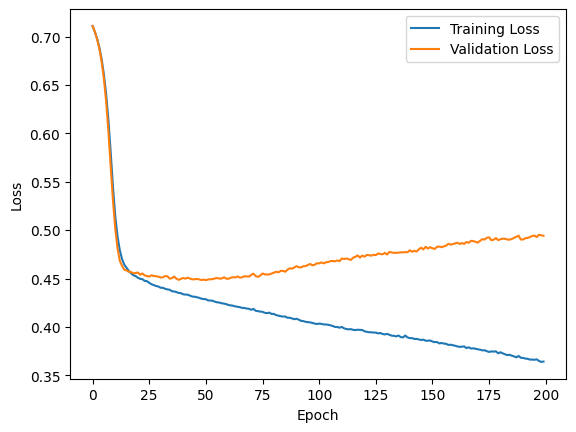

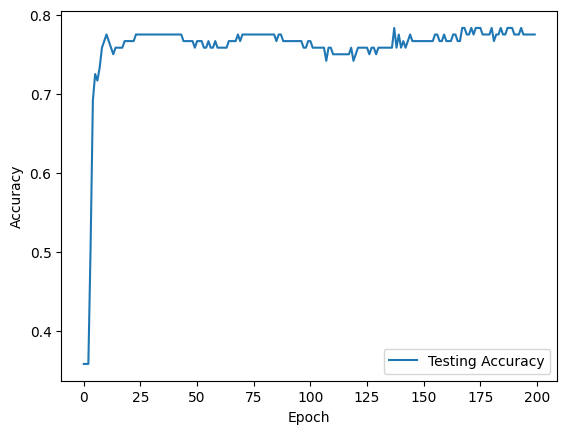

In [19]:
# Checking to see the loss to see if the model is learning or not. (How wrong the model is on the data it *IS* learning from)
plt.plot(training_loss, label="Training Loss")
# Checking to see the validation loss if the model is being overfitted or not (How wrong the model is based on the data it did *NOT* learn from.)
plt.plot(validation_loss, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Testing the accuracy and measuring if the model is able to perform on the data.
plt.plot(testing_accuracy, label="Testing Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## Looking at these graphs above, at the Validation Loss and the training loss, the curve of them seems to start at around 20 ~ 30 but I can't really tell.
* I am making a rough estimate at 30 Epochs before overfitting.
* Since I updated the progress of how the model was performing at every 20 epochs, I made this estimate based off of the fact that my data in the block above most likely showed over fitting between 20 and 40 Epochs.
    * Epoch: 20 Loss: 0.452485599120458 Validation Loss: 0.4556519687175751 Accuracy: 0.7666666666666667
    * Epoch: 40 Loss: 0.4348498026529948 Validation Loss: 0.4497050940990448 Accuracy: 0.775

## Now I want to try training again, so I clear the model and everything needed, then try again at 30 epochs.
* I also change printing the training_loss, validation_loss and testing_accuracy every 20 epochs to every epoch to better see how the model performs, since I am working with a smaller amount now.

In [21]:
# This is a second training, as I can see that the first model above shows overfitting based off of the training loss & validation loss of the model.
model = DiabetesNN()
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

Epochs = 30
training_loss = []
validation_loss = []
testing_accuracy = []

for epoch in range(Epochs): # Trains the model and checks for accuracy on each test sample per epoch.

    model.train()
    epoch_loss = 0

    for batch_X, batch_y in Train_Loader:
        prediction = model(batch_X)
        loss = criterion(prediction, batch_y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    model.eval()

    with torch.no_grad(): # Applies the trained neural network to the test data without updating the model weights.
        validate_outputs = model(X_validate)
        val_loss = criterion(validate_outputs, y_validate)
        test_probability = torch.sigmoid(validate_outputs)
        test_predictions = (test_probability >= 0.5).float()
        accuracy = accuracy_score(y_validate.numpy(), test_predictions.numpy())

    training_loss.append(epoch_loss / len(Train_Loader))
    validation_loss.append(val_loss.item())
    testing_accuracy.append(accuracy)

    if (epoch + 1) % 1 == 0:
        print("Epoch:", epoch + 1, "Loss:", training_loss[-1], "Validation Loss:", validation_loss[-1], "Accuracy:", accuracy)

Epoch: 1 Loss: 0.689408270517985 Validation Loss: 0.6775745153427124 Accuracy: 0.7083333333333334
Epoch: 2 Loss: 0.6736688534418742 Validation Loss: 0.662689208984375 Accuracy: 0.6916666666666667
Epoch: 3 Loss: 0.6581697901089986 Validation Loss: 0.6478307843208313 Accuracy: 0.6833333333333333
Epoch: 4 Loss: 0.643860916296641 Validation Loss: 0.6307510733604431 Accuracy: 0.6666666666666666
Epoch: 5 Loss: 0.6266698559125264 Validation Loss: 0.6102278232574463 Accuracy: 0.675
Epoch: 6 Loss: 0.6073914885520935 Validation Loss: 0.5881141424179077 Accuracy: 0.675
Epoch: 7 Loss: 0.5881789048512777 Validation Loss: 0.5642490983009338 Accuracy: 0.6916666666666667
Epoch: 8 Loss: 0.5688946465651195 Validation Loss: 0.5407475233078003 Accuracy: 0.7166666666666667
Epoch: 9 Loss: 0.5517491380373637 Validation Loss: 0.5212723016738892 Accuracy: 0.7583333333333333
Epoch: 10 Loss: 0.5371791183948517 Validation Loss: 0.5057341456413269 Accuracy: 0.775
Epoch: 11 Loss: 0.525543075799942 Validation Loss: 

## This looks like it has pretty good validation loss and accuracy! But it seems like it it may be able to use an even lower epoch.
* It seems like epoch 16~17 is the best for this model. 
    * Loss: 0.485436071952184 Validation Loss: 0.46303319931030273 Accuracy: 0.7833333333333333
    * Loss: 0.4793956240018209 Validation Loss: 0.4596928358078003 Accuracy: 0.7833333333333333
## We should be able to see that in the graph, too.

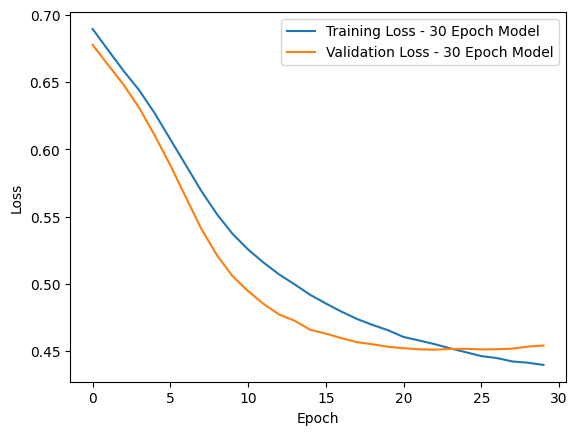

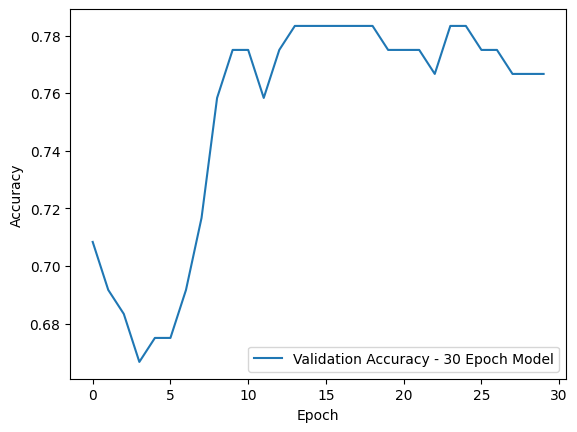

In [22]:
# Checking to see the loss to see if the model is learning or not. (How wrong the model is on the data it *IS* learning from)
plt.plot(training_loss, label="Training Loss - 30 Epoch Model")
# Checking to see the validation loss if the model is being overfitted or not (How wrong the model is based on the data it did *NOT* learn from.)
plt.plot(validation_loss, label="Validation Loss - 30 Epoch Model")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Testing the accuracy and measuring if the model is able to perform on the data.
plt.plot(testing_accuracy, label="Validation Accuracy - 30 Epoch Model")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## Looking at the graphs above, at the Validation Loss and the training loss, the curve of them seems to start at around 16 ~ 17
* This further confirms what I saw above in the data with
    * Loss: 0.485436071952184 Validation Loss: 0.46303319931030273 Accuracy: 0.7833333333333333
    * Loss: 0.4793956240018209 Validation Loss: 0.4596928358078003 Accuracy: 0.7833333333333333
* Even the validation accuracy graph sort of shows that it may start overfitting past 16 ~ 17.

## Now that I know exactly where my model is accurate without overfitting it. I am applying it to try for 16 Epochs.

In [72]:
model = DiabetesNN()
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

Epochs = 16
training_loss = []
validation_loss = []
validation_accuracy = []

for epoch in range(Epochs): # Trains the model and checks for accuracy on each test sample per epoch.

    model.train()
    epoch_loss = 0

    for batch_X, batch_y in Train_Loader:
        prediction = model(batch_X)
        loss = criterion(prediction, batch_y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    model.eval()

    with torch.no_grad(): # Applies the trained neural network to the test data without updating the model weights.
        validate_outputs = model(X_validate)
        val_loss = criterion(validate_outputs, y_validate)
        test_probability = torch.sigmoid(validate_outputs)
        test_predictions = (test_probability >= 0.5).float()
        accuracy = accuracy_score(y_validate.numpy(), test_predictions.numpy())

    training_loss.append(epoch_loss / len(Train_Loader))
    validation_loss.append(val_loss.item())
    validation_accuracy.append(accuracy)

    if (epoch + 1) % 1 == 0:
        print("Epoch:", epoch + 1, "Loss:", training_loss[-1], "Validation Loss:", validation_loss[-1], "Accuracy:", accuracy)

Epoch: 1 Loss: 0.6863379796346029 Validation Loss: 0.6806145906448364 Accuracy: 0.7
Epoch: 2 Loss: 0.6776407639185588 Validation Loss: 0.6716510057449341 Accuracy: 0.6666666666666666
Epoch: 3 Loss: 0.6691301147143046 Validation Loss: 0.6623756289482117 Accuracy: 0.6583333333333333
Epoch: 4 Loss: 0.6601086894671122 Validation Loss: 0.651696503162384 Accuracy: 0.6666666666666666
Epoch: 5 Loss: 0.649537460009257 Validation Loss: 0.6382860541343689 Accuracy: 0.6916666666666667
Epoch: 6 Loss: 0.6370661139488221 Validation Loss: 0.6211852431297302 Accuracy: 0.7416666666666667
Epoch: 7 Loss: 0.6206671277681987 Validation Loss: 0.6012113094329834 Accuracy: 0.7666666666666667
Epoch: 8 Loss: 0.6031766414642334 Validation Loss: 0.5766288042068481 Accuracy: 0.7833333333333333
Epoch: 9 Loss: 0.5817047874132792 Validation Loss: 0.5508144497871399 Accuracy: 0.7916666666666666
Epoch: 10 Loss: 0.5600909908612569 Validation Loss: 0.5243831276893616 Accuracy: 0.7833333333333333
Epoch: 11 Loss: 0.53782166

## This run looks like the best validation accuracy is around Epoch 16, at around Accuracy: 0.8166666666666667
* We can see it through the fact that the validation loss is still going down and the accuracy is still high!
    * Loss: 0.47184842427571616 Validation Loss: 0.44387608766555786 Accuracy: 0.8166666666666667
## We should be able to see that in the graph, as well.

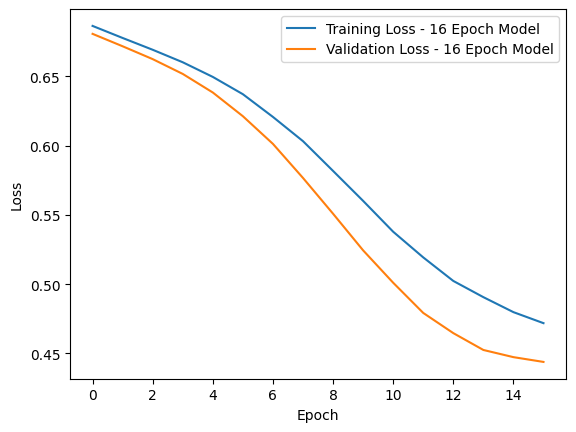

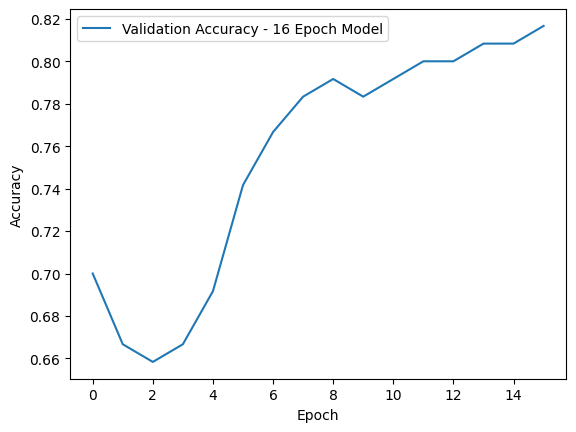

In [73]:
# Checking to see the loss to see if the model is learning or not. (How wrong the model is on the data it *IS* learning from)
plt.plot(training_loss, label="Training Loss - 16 Epoch Model")
# Checking to see the validation loss if the model is being overfitted or not (How wrong the model is based on the data it did *NOT* learn from.)
plt.plot(validation_loss, label="Validation Loss - 16 Epoch Model")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Testing the accuracy and measuring if the model is able to perform on the data.
plt.plot(validation_accuracy, label="Validation Accuracy - 16 Epoch Model")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## Looking at the graphs above, at the Validation Loss and the training loss, it looks like this 16 Epoch Model was correct!
* The curve just starts at 16 and the model is not overfitted, with good accuracy!
* The data also supports this, as well.
    * Loss: 0.47184842427571616 Validation Loss: 0.44387608766555786 Accuracy: 0.8166666666666667

## Displaying which Model, the Loss Function, which optimizer it's using, the learning rate, How many Epochs used, and then the validation accuracy, final training loss and validation loss.

In [74]:
Results = pd.DataFrame({"Model": ["16-Epoch PyTorch Neural Network"], "Loss Function": ["Binary Cross Entropy with Logits"], "Optimizer": ["Adam"], "Learning Rate": [0.001], "Epochs": [Epochs],
                        "Best Validation Accuracy": [max(validation_accuracy)], "Final Training Loss": [training_loss[-1]], "Final Validation Loss": [validation_loss[-1]]})
Results

,Model,Loss Function,Optimizer,Learning Rate,Epochs,Best Validation Accuracy,Final Training Loss,Final Validation Loss
0,16-Epoch PyTorch Neural Network,Binary Cross Entropy with Logits,Adam,0.001,16,0.816667,0.471848,0.443876


## Applying the trained model to the kaggle test data to predict things.

In [75]:
model.eval()

DiabetesNN(
  (model): Sequential(
    (0): Linear(in_features=8, out_features=12, bias=True)
    (1): ReLU()
    (2): Linear(in_features=12, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=8, bias=True)
    (5): ReLU()
    (6): Linear(in_features=8, out_features=1, bias=True)
  )
)

## Setting the trained neural network and comparing it to the kaggle test data.

## Then I build the end file of the project to submit it with completedKaggleProject

In [76]:
with torch.no_grad(): # Setting the trained neural network and comparing it to the kaggle test data.
    kaggle_outputs = model(X_Kaggle)
    kaggle_probability = torch.sigmoid(kaggle_outputs).numpy().reshape(-1)

# Building the end file of the project to submit.
completedKaggleProject = pd.DataFrame({"id": test[ID], "label": kaggle_probability})

## Making sure the first few entries (The ID and label columns) of completedKaggleProject look correct for submission.

In [77]:
completedKaggleProject.head()

,id,label
0,1,0.607003
1,2,0.166352
2,3,0.101539
3,4,0.164934
4,5,0.392741


## Then I check that my submission has the correct number of rows and columns.

In [78]:
completedKaggleProject.shape

(168, 2)

## Finally, I save the Kaggle submission file to a csv!

In [79]:
completedKaggleProject.to_csv("submission.csv", index=False)